### How these plots are built
- **Signal extraction:** We open the HDF5 file, pick the ROI index (`ROI_IDX`), and read the subcortical time series `tcp_subcortical_raw`. The array is (region, sample), so we take one ROI row for plotting. 
- **Time axis:** The repetition time `TR` (800 ms) converts sample indices to seconds: `time = index * TR`. The full-run x-axis is `np.arange(0, sample_count * TR, TR)`. For hammer task runs: `sample_count=493`.
- **Block selection:** Each `blocks/<name>` group has a `trial_type` attribute. We natural-sort the block names (block_1, block_2, …) and collect them into `face` or `shape` lists. By default, Python will sort strings in a way that puts "block_10" before "block_2", so we use natural sorting to ensure the order reflects the numeric suffixes.
- **Onset/end to sample indices:** Block metadata provides `onset_s` and `block_end_s` (seconds from scan start). To align to samples, we floor-divide by TR with a tiny epsilon: `idx = floor((onset_s + 1e-9) / TR)`. The epsilon prevents floating-point edge cases at exact multiples of TR. Block length in samples comes from the stored block array; we do not round `block_end_s` for slicing, but we do use it for shading spans in the overview axes. 
- **Plotting windows:** For each block, we slice the global time axis to the block’s sample length. Face and shape subplots both use absolute scan time on the x-axis, so ticks and markers match the true scan seconds. 
- **Visual cues:**
  - Top panels shade the block spans over the full run for context. 
  - Block subplots show every sample as a point and place an x-tick at every sample time; labels are rotated to avoid overlap. 
  - Legends appear only if there are blocks for that trial type. 
- **Why absolute time on subplots?** Using scan-time x-axes makes it easy to compare when blocks occur across the run and between trial types.

In [ ]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "plot_config.py").exists():
            return p
    raise RuntimeError("plot_config.py not found above " + str(start))

try:
    _start = Path(__file__).resolve().parent
except NameError:
    _start = Path.cwd().resolve()

REPO_ROOT = _find_repo_root(_start)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import plot_config  # noqa: F401
import numpy as np
import h5py
import re

from matplotlib import pyplot as plt

In [ ]:
SUBJECT_ID = "sub-NDARINVPZ987BMX"
FILE_SUFFIX = "_task-hammerAP_run-01_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.h5"

# FILE_DIR = Path("/cluster/work/ianpe/masters_thesis/preprocessing/tcp/parcellations") # IDUN
FILE_DIR = Path("/Users/ipeglin/Documents/masters_thesis/preprocessing/tcp/parcellations") # LOCAL
FILE_PATH = FILE_DIR / SUBJECT_ID / f"{SUBJECT_ID}{FILE_SUFFIX}"

TR = 800e-3
ROI_IDX = 2 # lAMY-rh

In [ ]:
def natural_sort_key(s):
    # Splits "block_10" into ["block_", 10, ""]
    return [int(text) if text.isdigit() else text.lower() 
            for text in re.split('([0-9]+)', s)]

SUBCORTICAL TIME SERIES: <HDF5 dataset "tcp_subcortical_raw": shape (32, 493), type "<f4">


/var/folders/_w/yxnxx2rn2t11qwh4kx9h9g680000gn/T/ipykernel_68578/1438194848.py:22: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(len(face_blocks) + 1, 1, figsize=((15, 25)), sharex=False)
/var/folders/_w/yxnxx2rn2t11qwh4kx9h9g680000gn/T/ipykernel_68578/1438194848.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  face_cmap = plt.cm.get_cmap("tab10", max(len(face_blocks), 1))
/var/folders/_w/yxnxx2rn2t11qwh4kx9h9g680000gn/T/ipykernel_68578/1438194848.py:64: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig2, ax2 = plt.subplots(len(shape_blocks) + 1, 1, figsize=((15, 25)), sharex=False)
/var/folders/_w/yxnxx2rn2t11qwh4kx9h9g680000gn/T/ipykernel_68578/1438194848.py:67: Matplo

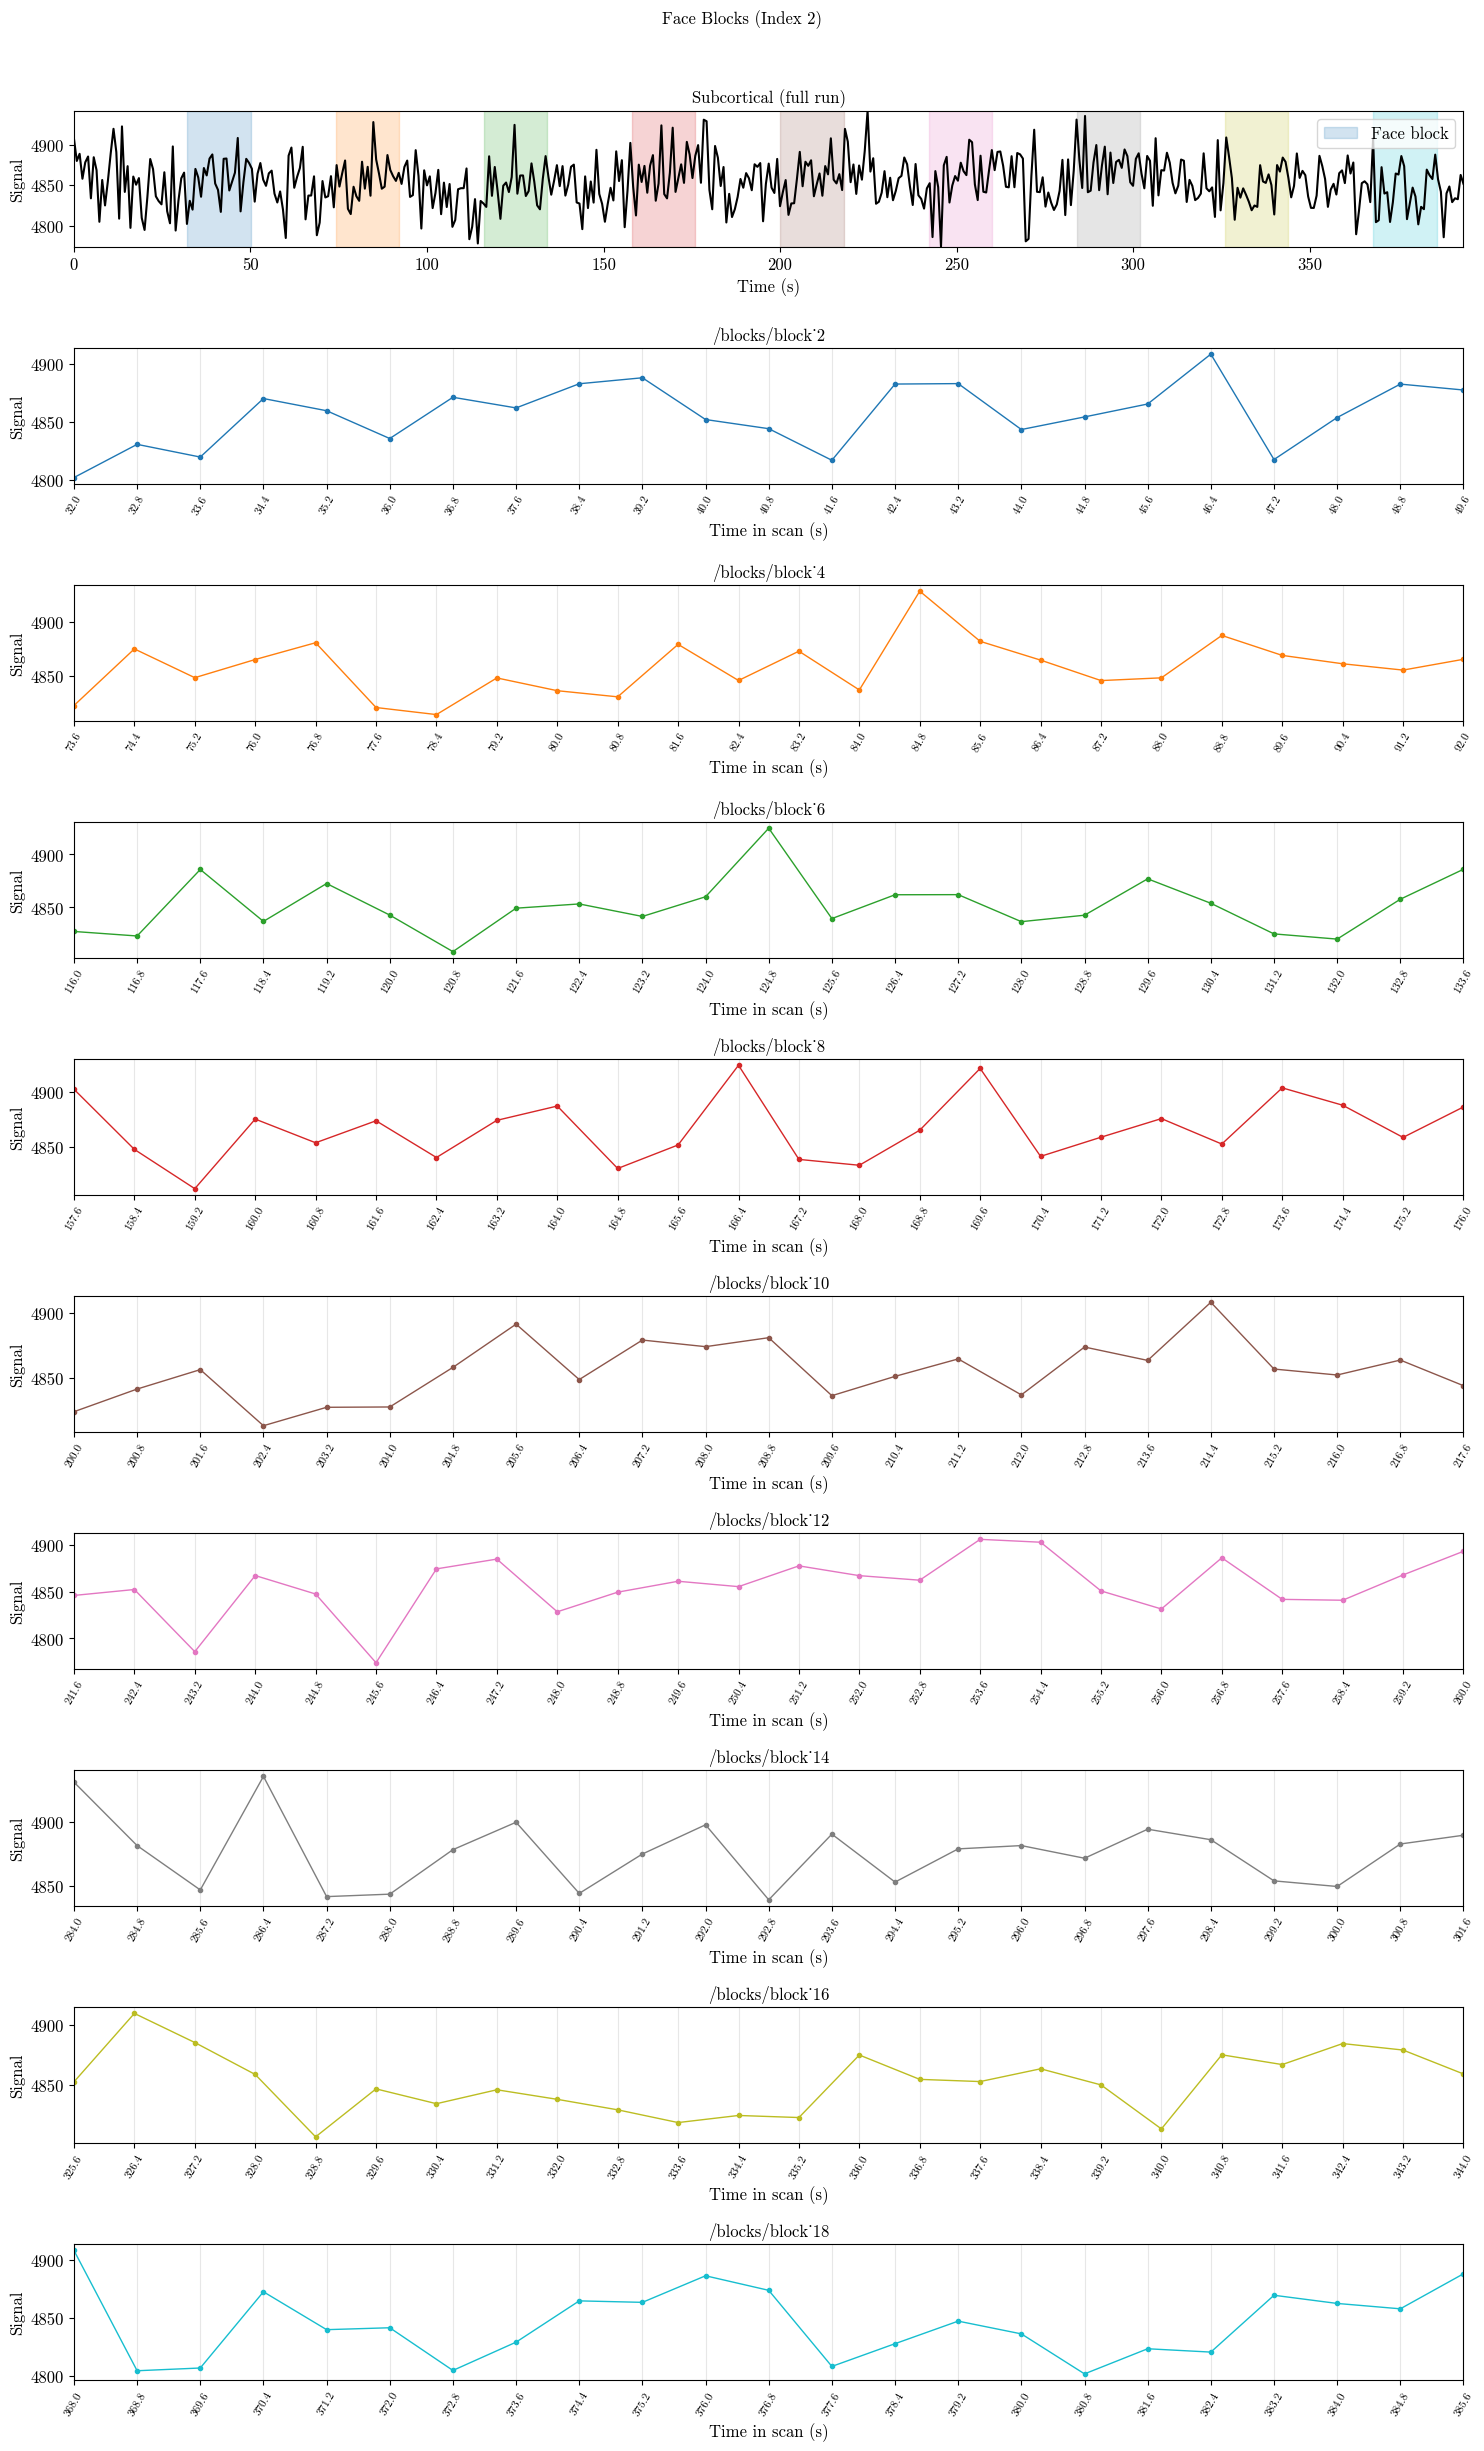

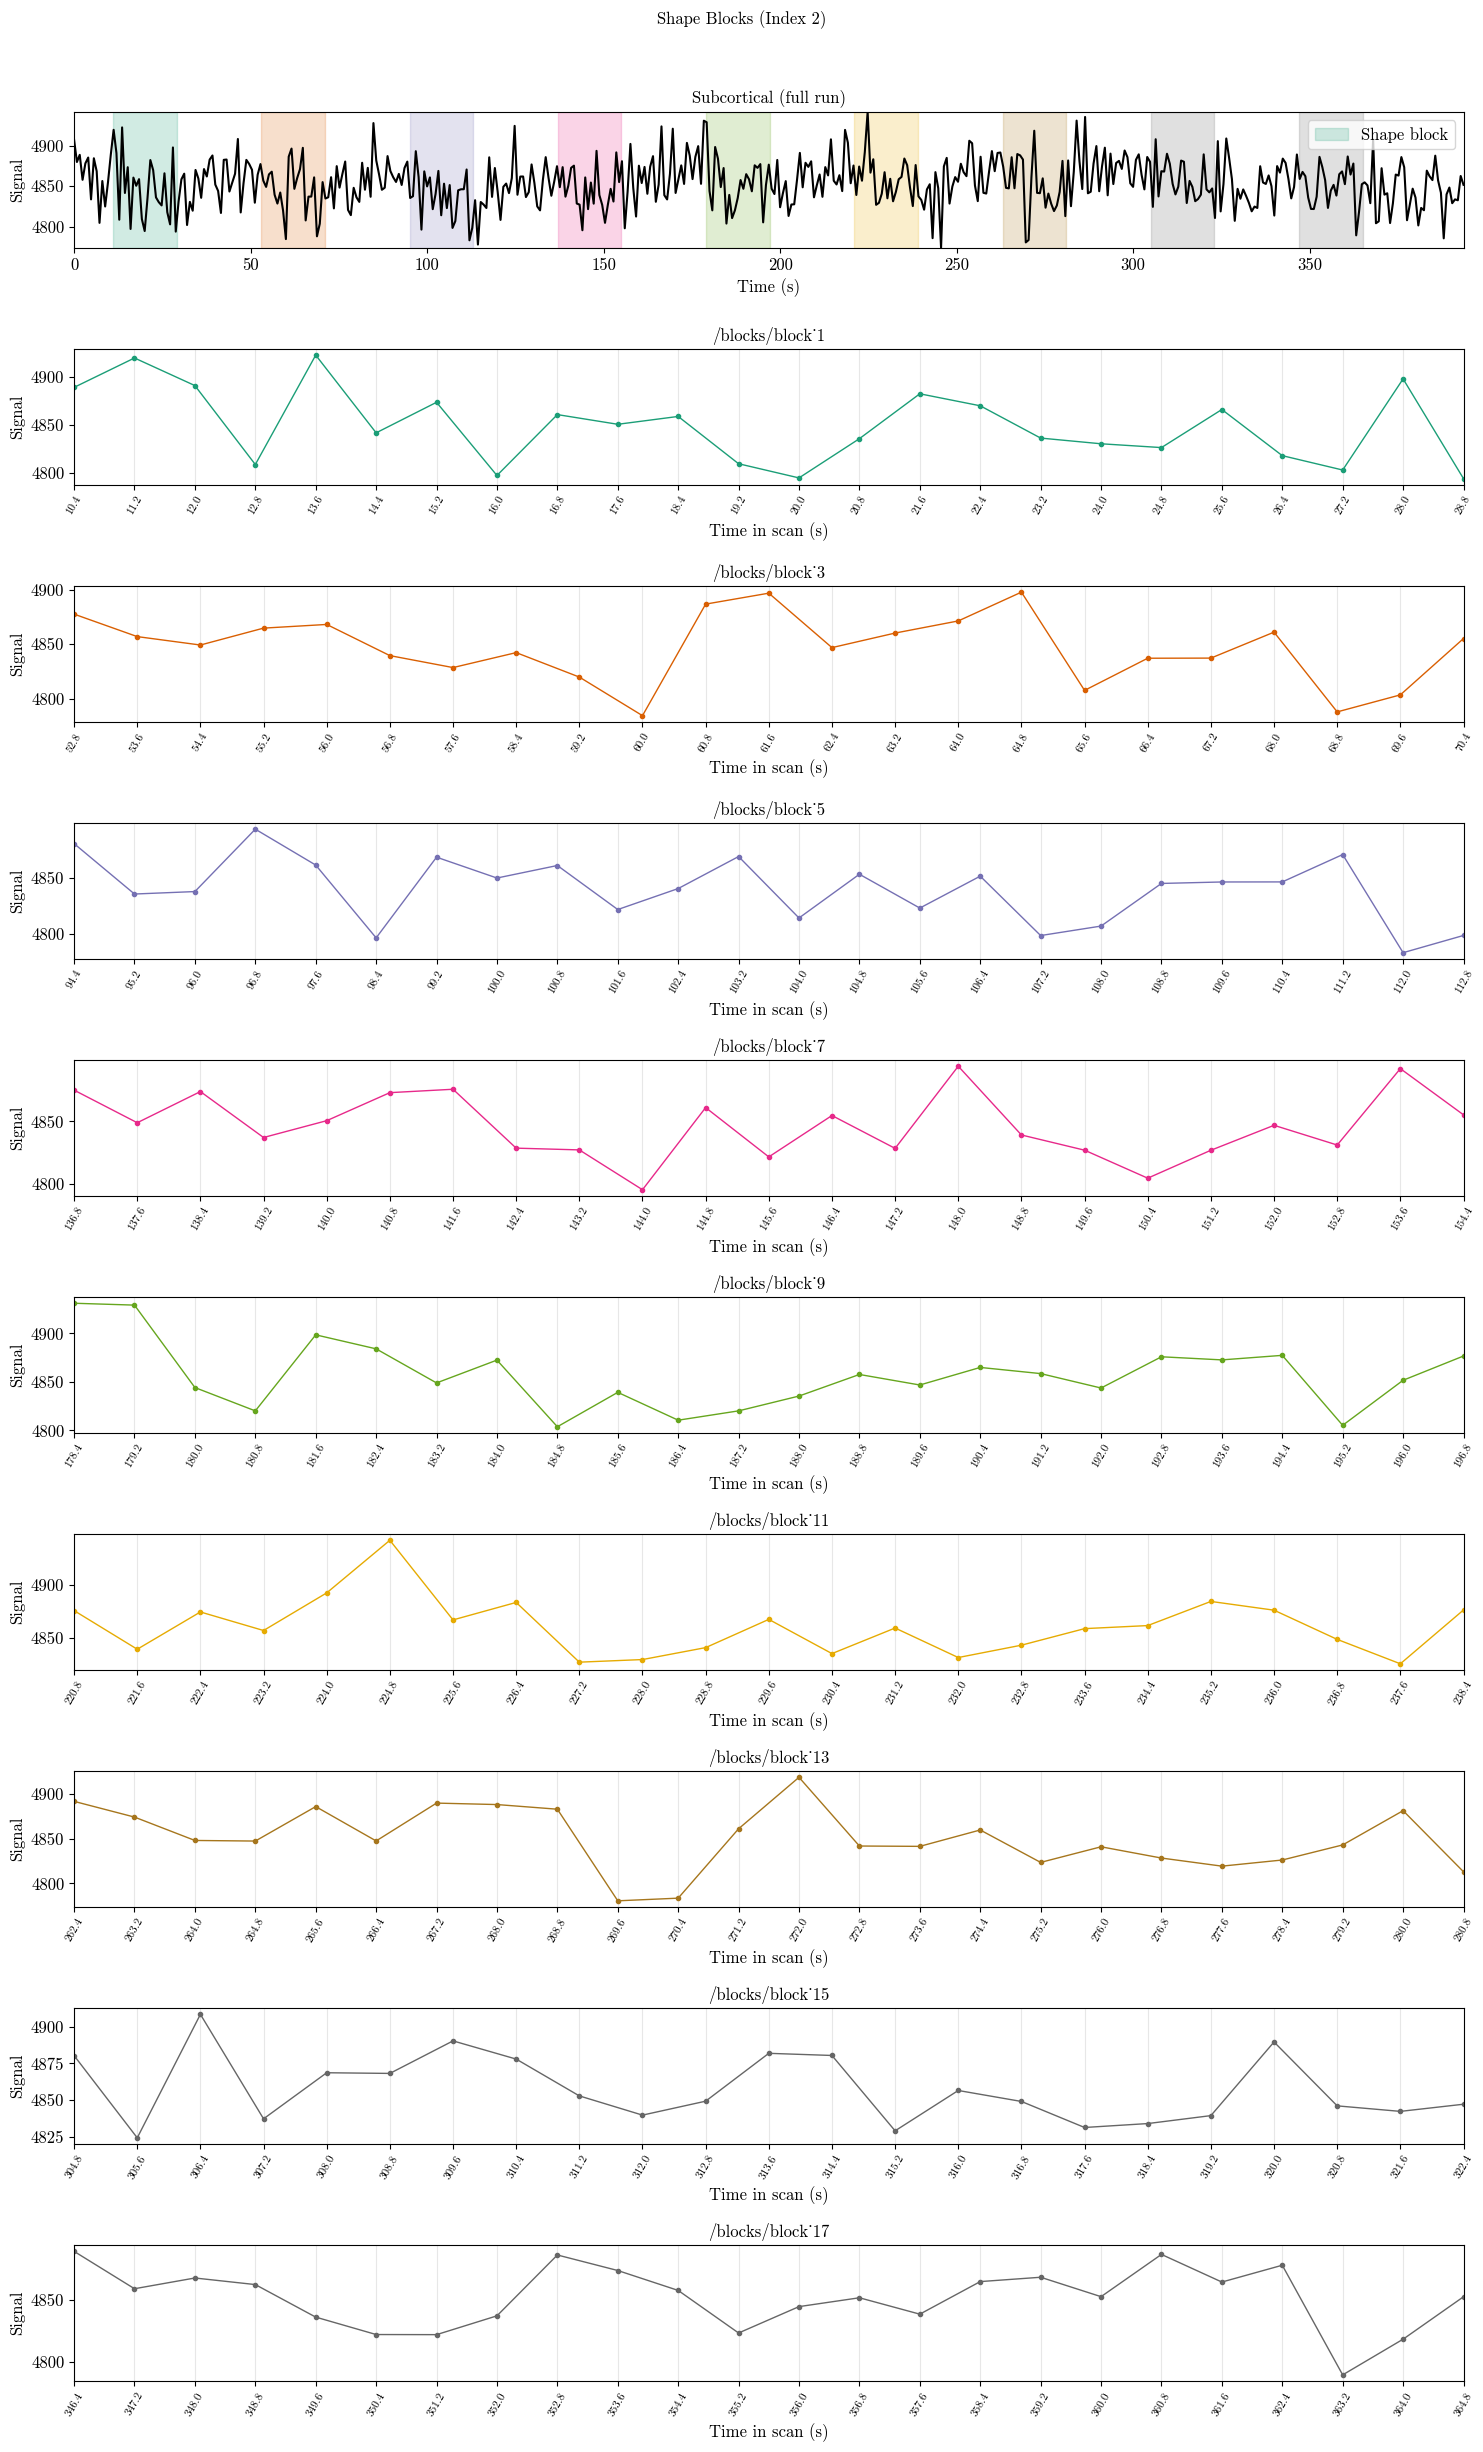

In [ ]:
with h5py.File(FILE_PATH, 'r') as f:
  # Raw subcortical time series for the chosen ROI
  subcortical_ts = f["tcp_subcortical_raw"]
  subcortical_ts_roi = subcortical_ts[ROI_IDX]
  print("SUBCORTICAL TIME SERIES:", subcortical_ts)
  
  # Collect block groups by trial type
  blocks = sorted(list(f["blocks"].keys()), key=natural_sort_key)
  trial_blocks = {"face": [], "shape": []}
  for group_name in blocks:
    block_group = f["blocks"][group_name]
    trial_type = block_group.attrs.get("trial_type", None)
    if trial_type in trial_blocks:
      trial_blocks[trial_type].append(block_group)
  
  # Build absolute time axis (seconds) for the full run
  roi_count, sample_count = subcortical_ts.shape
  x_axis = np.arange(0, sample_count*TR, TR)
  
  # Face figure (absolute scan time axis)
  face_blocks = trial_blocks["face"]
  fig, ax = plt.subplots(len(face_blocks) + 1, 1, figsize=((15, 25)), sharex=False)
  fig.suptitle(f"Face Blocks (Index {ROI_IDX})")
  ax = np.atleast_1d(ax)
  face_cmap = plt.cm.get_cmap("tab10", max(len(face_blocks), 1))
  ax[0].plot(x_axis, subcortical_ts_roi, color="black")
  ax[0].set_title("Subcortical (full run)")
  ax[0].set_xlabel("Time (s)")
  ax[0].set_ylabel("Signal")
  
  for idx, fb in enumerate(face_blocks):
    fb_subcortical = fb["subcortical_raw"]
    fb_subcortical_ts_roi = fb_subcortical[ROI_IDX]
    onset_seconds = fb.attrs["onset_s"]
    block_end_seconds = fb.attrs["block_end_s"]
    # Map onset to sample index; tiny epsilon avoids floating edge cases at TR boundaries
    onset_idx = np.floor((onset_seconds + 1e-9) / TR).astype(int)
    segment_len = fb_subcortical_ts_roi.shape[-1]
    # Absolute time stamps for this block segment (aligns ticks to scan time)
    x_segment_abs = x_axis[onset_idx:onset_idx + segment_len]
    block_color = face_cmap(idx)
    ax[0].axvspan(onset_seconds, block_end_seconds, color=block_color, alpha=0.2, label="Face block" if idx == 0 else None)
    ax[idx+1].plot(x_segment_abs, fb_subcortical_ts_roi, color=block_color, marker="o", markersize=3, linewidth=1)
    if x_segment_abs.size > 0:
      ax[idx+1].set_xlim(x_segment_abs[0], x_segment_abs[-1])
      ax[idx+1].set_xticks(x_segment_abs)
    ax[idx+1].tick_params(axis="x", labelrotation=60, labelsize=8)
    ax[idx+1].grid(True, axis="x", which="both", alpha=0.3)
    ax[idx+1].set_title(fb.name)
    ax[idx+1].set_xlabel("Time in scan (s)")
    ax[idx+1].set_ylabel("Signal")
    # print(f"FACE BLOCK: {fb.name} | ONSET: {onset_seconds}s | END: {block_end_seconds}s")
  
  if face_blocks:
    ax[0].set_xlim(x_axis.min(), x_axis.max())
    ax[0].set_ylim(subcortical_ts_roi.min(), subcortical_ts_roi.max())
    handles, labels = ax[0].get_legend_handles_labels()
    if handles:
      ax[0].legend(loc="upper right")
  fig.tight_layout(rect=(0, 0, 1, 0.97))
  
  # Shape figure (absolute scan time axis)
  shape_blocks = trial_blocks["shape"]
  fig2, ax2 = plt.subplots(len(shape_blocks) + 1, 1, figsize=((15, 25)), sharex=False)
  fig2.suptitle(f"Shape Blocks (Index {ROI_IDX})")
  ax2 = np.atleast_1d(ax2)
  shape_cmap = plt.cm.get_cmap("Dark2", max(len(shape_blocks), 1))
  ax2[0].plot(x_axis, subcortical_ts_roi, color="black")
  ax2[0].set_title("Subcortical (full run)")
  ax2[0].set_xlabel("Time (s)")
  ax2[0].set_ylabel("Signal")
  
  for idx, sb in enumerate(shape_blocks):
    sb_subcortical = sb["subcortical_raw"]
    sb_subcortical_ts_roi = sb_subcortical[ROI_IDX]
    onset_seconds = sb.attrs["onset_s"]
    block_end_seconds = sb.attrs["block_end_s"]
    onset_idx = np.floor((onset_seconds + 1e-9) / TR).astype(int)
    segment_len = sb_subcortical_ts_roi.shape[-1]
    # Absolute time stamps for this block segment
    x_segment_abs = x_axis[onset_idx:onset_idx + segment_len]
    block_color = shape_cmap(idx)
    ax2[0].axvspan(onset_seconds, block_end_seconds, color=block_color, alpha=0.2, label="Shape block" if idx == 0 else None)
    ax2[idx+1].plot(x_segment_abs, sb_subcortical_ts_roi, color=block_color, marker="o", markersize=3, linewidth=1)
    if x_segment_abs.size > 0:
      ax2[idx+1].set_xlim(x_segment_abs[0], x_segment_abs[-1])
      ax2[idx+1].set_xticks(x_segment_abs)
    ax2[idx+1].tick_params(axis="x", labelrotation=60, labelsize=8)
    ax2[idx+1].grid(True, axis="x", which="both", alpha=0.3)
    ax2[idx+1].set_title(sb.name)
    ax2[idx+1].set_xlabel("Time in scan (s)")
    ax2[idx+1].set_ylabel("Signal")
    # print(f"SHAPE BLOCK: {sb.name} | ONSET: {onset_seconds}s | END: {block_end_seconds}s")
  
  if shape_blocks:
    ax2[0].set_xlim(x_axis.min(), x_axis.max())
    ax2[0].set_ylim(subcortical_ts_roi.min(), subcortical_ts_roi.max())
    handles2, labels2 = ax2[0].get_legend_handles_labels()
    if handles2:
      ax2[0].legend(loc="upper right")
  fig2.tight_layout(rect=(0, 0, 1, 0.97))
  
  

/var/folders/_w/yxnxx2rn2t11qwh4kx9h9g680000gn/T/ipykernel_68578/2358324431.py:19: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)


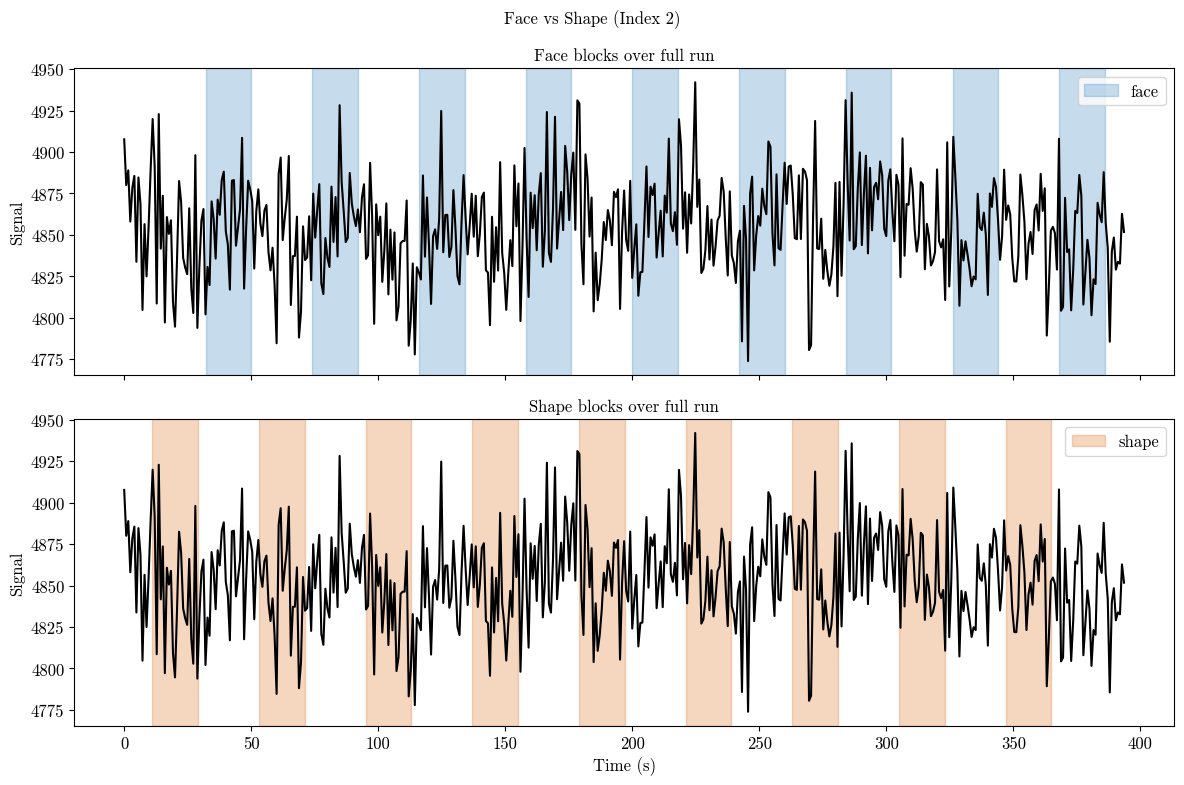

In [ ]:
# Comparison of trial types (full run with spans)
with h5py.File(FILE_PATH, 'r') as f:
  subcortical_ts = f["tcp_subcortical_raw"]
  subcortical_ts_roi = subcortical_ts[ROI_IDX]
  blocks = sorted(list(f["blocks"].keys()), key=natural_sort_key)
  trial_blocks = {"face": [], "shape": []}
  for group_name in blocks:
    block_group = f["blocks"][group_name]
    trial_type = block_group.attrs.get("trial_type", None)
    if trial_type in trial_blocks:
      trial_blocks[trial_type].append(block_group)

  _, sample_count = subcortical_ts.shape
  x_axis = np.arange(0, sample_count*TR, TR)

  face_color = plt.cm.tab10(0)
  shape_color = plt.cm.Dark2(1)

  fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
  fig.suptitle(f"Face vs Shape (Index {ROI_IDX})")

  ax[0].plot(x_axis, subcortical_ts_roi, color="black")
  for fb in trial_blocks["face"]:
    onset_seconds = fb.attrs["onset_s"]
    block_end_seconds = fb.attrs["block_end_s"]
    ax[0].axvspan(onset_seconds, block_end_seconds, color=face_color, alpha=0.25, label="face")
  ax[0].set_ylabel("Signal")
  ax[0].set_title("Face blocks over full run")

  ax[1].plot(x_axis, subcortical_ts_roi, color="black")
  for sb in trial_blocks["shape"]:
    onset_seconds = sb.attrs["onset_s"]
    block_end_seconds = sb.attrs["block_end_s"]
    ax[1].axvspan(onset_seconds, block_end_seconds, color=shape_color, alpha=0.25, label="shape")
  ax[1].set_xlabel("Time (s)")
  ax[1].set_ylabel("Signal")
  ax[1].set_title("Shape blocks over full run")

  # Deduplicate legend labels
  for axis in ax:
    handles, labels = axis.get_legend_handles_labels()
    if handles:
      uniq = dict(zip(labels, handles))
      axis.legend(uniq.values(), uniq.keys(), loc="upper right")

  fig.tight_layout()
